# Option 2 — Symbolic Conditioned MIDI Generation

**Task**: Given a 4-second MIDI prefix, autoregressively generate a 4-second continuation using a small GPT-2 Transformer trained on REMI tokens from MAESTRO v3.0.0.

**Pipeline**: Setup → Download MAESTRO → Build REMI token cache → Build windows → Train → Generate → Evaluate

## 1. Environment Setup

In [7]:
import os, sys, importlib
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
print('Running on Colab:', IN_COLAB)

if IN_COLAB:
    REPO_URL = 'https://github.com/archerop/CSE_253.git'
    REPO_DIR = Path('/content/CSE_253')
    if not REPO_DIR.exists():
        !git clone {REPO_URL} {REPO_DIR}
    else:
        result = !git -C {REPO_DIR} pull --ff-only
        print('\n'.join(result))
        # Flush stale cached modules so re-imports read the updated files
        stale = [k for k in sys.modules if k == 'app' or k.startswith('app.')]
        for k in stale:
            del sys.modules[k]
        importlib.invalidate_caches()
        if stale:
            print(f'Flushed {len(stale)} cached module(s)')
    ASSIGNMENT_ROOT = REPO_DIR / 'assignment2'
else:
    ASSIGNMENT_ROOT = Path('__file__').resolve().parent if '__file__' in dir() else Path('.').resolve()
    for p in [ASSIGNMENT_ROOT] + list(ASSIGNMENT_ROOT.parents):
        if (p / 'app').exists():
            ASSIGNMENT_ROOT = p
            break

print('Assignment root:', ASSIGNMENT_ROOT)
os.chdir(ASSIGNMENT_ROOT)
if str(ASSIGNMENT_ROOT) not in sys.path:
    sys.path.insert(0, str(ASSIGNMENT_ROOT))

Already up to date.
Flushed 10 cached module(s)
Assignment root: /content/CSE_253/assignment2


## 2. Install Dependencies

In [8]:
import importlib, subprocess

def need(pkg):
    return importlib.util.find_spec(pkg) is None

pkgs = [p for p in ['pretty_midi', 'torch', 'pandas', 'tqdm', 'scipy', 'miditok', 'symusic', 'transformers'] if need(p)]
if pkgs:
    print('Installing:', pkgs)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
else:
    print('All dependencies already installed.')

All dependencies already installed.


## 3. Download MAESTRO MIDI Dataset

In [9]:
import urllib.request, zipfile

MAESTRO_ROOT = ASSIGNMENT_ROOT / 'data' / 'maestro-v3.0.0'

if (MAESTRO_ROOT / 'maestro-v3.0.0.csv').exists():
    print('MAESTRO already present at', MAESTRO_ROOT)
else:
    URL = 'https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip'
    ZIP = ASSIGNMENT_ROOT / 'data' / 'downloads' / 'maestro-v3.0.0-midi.zip'
    ZIP.parent.mkdir(parents=True, exist_ok=True)
    if not ZIP.exists():
        print('Downloading MAESTRO MIDI (~57 MB)...')
        urllib.request.urlretrieve(URL, ZIP)
    print('Extracting...')
    with zipfile.ZipFile(ZIP) as zf:
        zf.extractall(ASSIGNMENT_ROOT / 'data')
    print('Done.')

print(f'MIDI files: {len(list(MAESTRO_ROOT.rglob("*.midi")))}')

MAESTRO already present at /content/CSE_253/assignment2/data/maestro-v3.0.0
MIDI files: 1276


## 4. Imports

In [ ]:
import json, pickle
import numpy as np
import torch
from torch.utils.data import DataLoader
import pretty_midi
from tqdm.auto import tqdm

from app.shared.config import (
    MAESTRO_ROOT, OPTION2_CACHE_DIR, OPTION2_OUTPUT_DIR, CHECKPOINT_DIR,
    OPTION2_FRAME_RATE, OPTION2_PREFIX_SECONDS, OPTION2_CONTINUATION_SECONDS,
    OPTION2_BATCH_SIZE, OPTION2_LEARNING_RATE, OPTION2_WEIGHT_DECAY,
    OPTION2_MAX_EPOCHS, OPTION2_PATIENCE, OPTION2_PREFIX_MAX_LEN, OPTION2_CONT_MAX_LEN,
    OPTION2_MODEL_TYPE,
)
from app.shared.metadata import load_maestro_metadata, validate_maestro_paths
from app.option2.symbolic_dataset import (
    build_tokenizer, precache_tokens, build_token_window_index, SymbolicDataset, get_datasets,
)
from app.option2.symbolic_models import build_model, generate_tokens, CopyLastPatternBaseline
from app.option2.symbolic_train import train, load_best_checkpoint
from app.option2.symbolic_generate import (
    extract_prefix, generate_conditioned, save_symbolic_conditioned, tokens_to_pianoroll,
)
from app.option2.symbolic_eval import (
    evaluate_generation, evaluate_token_generation, print_metrics,
    evaluate_dataset, print_dataset_metrics,
)

print('Imports OK')

In [11]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print('Device:', DEVICE)

# ── Model selection ──────────────────────────────────────────────────────────
# Change MODEL_TYPE to switch architectures. All share the same token pipeline.
#   'lstm'        ~1.2M params  (fast, simple, good baseline)
#   'gru'         ~1.0M params  (slightly smaller than LSTM)
#   'transformer' ~0.9M params  (causal, token-level)
#   'gpt2'        ~11M params   (deepest, best quality, slower to train)
MODEL_TYPE = 'transformer'
# ─────────────────────────────────────────────────────────────────────────────
print('Model type:', MODEL_TYPE)

Device: cuda
Model type: transformer


## 5. Google Drive Setup (Colab only)
Mounts Google Drive and routes the checkpoint there so it survives session resets.

In [12]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    GDRIVE_DIR = Path('/content/drive/MyDrive/CSE253')
    GDRIVE_DIR.mkdir(parents=True, exist_ok=True)
    CKPT_PATH = GDRIVE_DIR / f'option2_{MODEL_TYPE}_best.pt'
    print('Checkpoint → Google Drive:', CKPT_PATH)
else:
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    CKPT_PATH = CHECKPOINT_DIR / f'option2_{MODEL_TYPE}_best.pt'
    print('Checkpoint → local:', CKPT_PATH)

Mounted at /content/drive
Checkpoint → Google Drive: /content/drive/MyDrive/CSE253/option2_transformer_best.pt


## 6. Build REMI Tokenizer & Pre-cache Tokens
Tokenizes all 1,276 MIDI files once using the REMI tokenizer and saves per-file `.pkl` caches. Safe to re-run — skips existing files.

In [13]:
tokenizer = build_tokenizer()
print(f'Tokenizer ready. vocab_size={tokenizer.vocab_size}  PAD={tokenizer["PAD_None"]}  BOS={tokenizer["BOS_None"]}  EOS={tokenizer["EOS_None"]}')
precache_tokens(tokenizer)

Tokenizer ready. vocab_size=347  PAD=0  BOS=1  EOS=2
Tokenizing 1276 MIDI files → /content/CSE_253/assignment2/cache/option2/tokens ...


100%|██████████| 1276/1276 [01:59<00:00, 10.66file/s]

Token pre-caching complete.


## 7. Build Token Window Index
Slides a window of `PREFIX_MAX_LEN + CONT_MAX_LEN = 512` tokens over each MIDI's token sequence with stride 128.

In [14]:
OPTION2_CACHE_DIR.mkdir(parents=True, exist_ok=True)

train_windows = build_token_window_index('train',      tokenizer, cache_path=OPTION2_CACHE_DIR / 'train_token_windows.pkl')
val_windows   = build_token_window_index('validation', tokenizer, cache_path=OPTION2_CACHE_DIR / 'val_token_windows.pkl')
test_windows  = build_token_window_index('test',       tokenizer, cache_path=OPTION2_CACHE_DIR / 'test_token_windows.pkl')

print(f'Windows — train: {len(train_windows):,}  val: {len(val_windows):,}  test: {len(test_windows):,}')

Indexing [test]: 100%|██████████| 177/177 [00:00<00:00, 1897.14it/s]

Windows — train: 162,736  val: 18,302  test: 21,017


## 8. Dataset & DataLoader

In [15]:
train_ds = SymbolicDataset(train_windows, tokenizer)
val_ds   = SymbolicDataset(val_windows,   tokenizer)

prefix, cont = train_ds[0]
print(f'prefix shape: {tuple(prefix.shape)}  dtype: {prefix.dtype}')
print(f'cont shape:   {tuple(cont.shape)}   dtype: {cont.dtype}')
print(f'non-pad prefix tokens: {(prefix != tokenizer["PAD_None"]).sum().item()}')

prefix shape: (256,)  dtype: torch.int64
cont shape:   (256,)   dtype: torch.int64
non-pad prefix tokens: 256


In [16]:
PIN_MEMORY  = DEVICE.type == 'cuda'
NUM_WORKERS = 2 if IN_COLAB else 4

train_loader = DataLoader(train_ds, batch_size=OPTION2_BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=OPTION2_BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'Train batches: {len(train_loader):,}  Val batches: {len(val_loader):,}')

Train batches: 5,086  Val batches: 572


## 9. Model

All models use REMI tokenization (vocab 347) and are trained with the same teacher-forcing cross-entropy loss. Switch `MODEL_TYPE` in the device cell above to compare.

| MODEL_TYPE | Architecture | Params | Notes |
|------------|-------------|--------|-------|
| `lstm` | 2-layer LSTM, hidden=256 | ~1.2M | Fast, strong sequential baseline |
| `gru` | 2-layer GRU, hidden=256 | ~1.0M | Slightly lighter than LSTM |
| `transformer` | 4-layer causal Transformer, d=128 | ~0.9M | Lightest, explicit position encoding |
| `gpt2` | 6-layer GPT-2, d=384 | ~11M | Best quality, ~10× slower |

In [17]:
model = build_model(MODEL_TYPE, vocab_size=tokenizer.vocab_size).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model: {MODEL_TYPE}  |  Parameters: {n_params:,} ({n_params/1e6:.2f}M)')

/content/CSE_253/assignment2/app/option2/symbolic_models.py:137: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Model: transformer  |  Parameters: 882,267 (0.88M)


## 10. Training

In [18]:
history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    checkpoint_path=CKPT_PATH,
)

OPTION2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
with open(OPTION2_OUTPUT_DIR / 'train_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('Training complete. Checkpoint saved to:', CKPT_PATH)

Epoch   1/5 | train=2.3751  val=2.1884  best=2.1884 ✓
Epoch   2/5 | train=2.1354  val=2.0849  best=2.0849 ✓
Epoch   3/5 | train=2.0644  val=2.0283  best=2.0283 ✓
Epoch   4/5 | train=2.0237  val=1.9996  best=1.9996 ✓
Epoch   5/5 | train=1.9960  val=1.9797  best=1.9797 ✓
Training complete. Checkpoint saved to: /content/drive/MyDrive/CSE253/option2_transformer_best.pt


## 11. Loss Curves

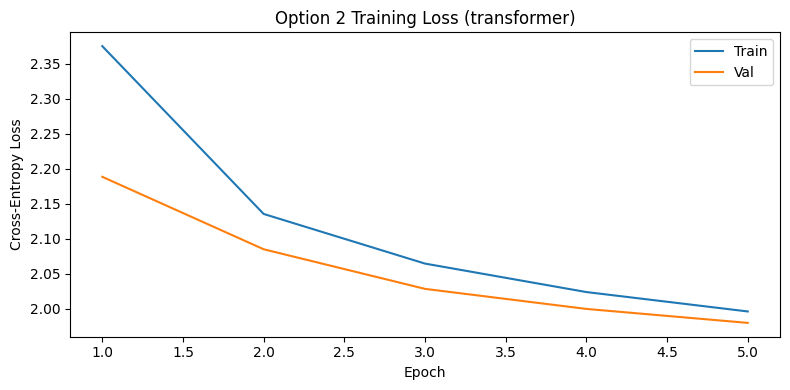

In [19]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, history['train_loss'], label='Train')
plt.plot(epochs, history['val_loss'],   label='Val')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title(f'Option 2 Training Loss ({MODEL_TYPE})')
plt.legend()
plt.tight_layout()
plt.savefig(OPTION2_OUTPUT_DIR / f'loss_curve_{MODEL_TYPE}.png', dpi=150)
plt.show()

## 12. Generate `symbolic_conditioned.mid`

In [20]:
df = load_maestro_metadata(MAESTRO_ROOT)
df = validate_maestro_paths(df)
test_df = df[(df['split'] == 'test') & df['midi_exists']].sort_values('duration').reset_index(drop=True)
row = test_df.iloc[len(test_df) // 2]
MIDI_PATH = row['midi_path']
print(f"Using: {row['composer']} — {row['title']}  ({row['duration']:.1f}s)")

Using: Ludwig van Beethoven — Sonata No. 16 Op. 31 No. 1 in G Major, I. Allegro vivace  (306.1s)


In [21]:
model = load_best_checkpoint(build_model(MODEL_TYPE, vocab_size=tokenizer.vocab_size), CKPT_PATH, DEVICE)

output_path = save_symbolic_conditioned(
    prefix_midi_path=MIDI_PATH,
    model=model,
    tokenizer=tokenizer,
    device=DEVICE,
)
print('Output saved to:', output_path)

Loaded checkpoint from epoch 5 (val_loss=1.9797)


/content/CSE_253/assignment2/app/option2/symbolic_models.py:137: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Saved: /content/CSE_253/assignment2/outputs/option2/symbolic_conditioned.mid
Output saved to: /content/CSE_253/assignment2/outputs/option2/symbolic_conditioned.mid


## 13. Evaluation — Model vs Baseline

In [ ]:
import symusic
from app.option2.symbolic_dataset import build_token_window_index, _trim_score
from app.option2.symbolic_eval import evaluate_dataset, print_dataset_metrics

test_windows = build_token_window_index('test', tokenizer,
                   cache_path=OPTION2_CACHE_DIR / 'test_token_windows.pkl')

# One representative window per MIDI file (middle window)
by_file = {}
for w in test_windows:
    by_file.setdefault(w[0], []).append(w)
test_samples = [ws[len(ws) // 2] for ws in by_file.values()]
print(f'Evaluating on {len(test_samples)} test pieces')

In [ ]:
model.eval()
gen_rolls, gt_rolls, baseline_rolls = [], [], []

for midi_path, start_tok, prefix_end_tok, cont_end_tok in tqdm(test_samples):
    # Ground truth continuation tokens → piano-roll
    score   = symusic.Score(midi_path)
    cont_sm = _trim_score(score, OPTION2_PREFIX_SECONDS,
                          OPTION2_PREFIX_SECONDS + OPTION2_CONTINUATION_SECONDS)
    gt_seqs = tokenizer.encode(cont_sm)
    gt_ids  = gt_seqs[0].ids if gt_seqs else []
    gt_roll = tokens_to_pianoroll(gt_ids, tokenizer)

    # Model generation
    prefix_ids = extract_prefix(midi_path, tokenizer)
    cont_ids   = generate_conditioned(model, prefix_ids, OPTION2_CONT_MAX_LEN, DEVICE)
    gen_roll   = tokens_to_pianoroll(cont_ids.tolist(), tokenizer)

    # Baseline: cycle last prefix tokens
    bl_ids  = CopyLastPatternBaseline().generate(
                  prefix_ids.unsqueeze(0), OPTION2_CONT_MAX_LEN).squeeze(0)
    bl_roll = tokens_to_pianoroll(bl_ids.tolist(), tokenizer)

    gen_rolls.append(gen_roll)
    gt_rolls.append(gt_roll)
    baseline_rolls.append(bl_roll)

print(f'Generated {len(gen_rolls)} continuations')

In [ ]:
import json

print(f'=== Model ({MODEL_TYPE}) ===')
model_metrics = evaluate_dataset(gen_rolls, gt_rolls)
print_dataset_metrics(model_metrics)

print('=== Baseline (copy last pattern) ===')
baseline_metrics = evaluate_dataset(baseline_rolls, gt_rolls)
print_dataset_metrics(baseline_metrics)

OPTION2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results = {'model': model_metrics, 'baseline': baseline_metrics}
out_path = OPTION2_OUTPUT_DIR / f'eval_results_{MODEL_TYPE}.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved eval results → {out_path}')

# Keep last sample in scope for the piano-roll visualization below
model_roll = gen_rolls[-1]
prefix_ids = extract_prefix(test_samples[-1][0], tokenizer)
cont_ids   = generate_conditioned(model, prefix_ids, OPTION2_CONT_MAX_LEN, DEVICE)

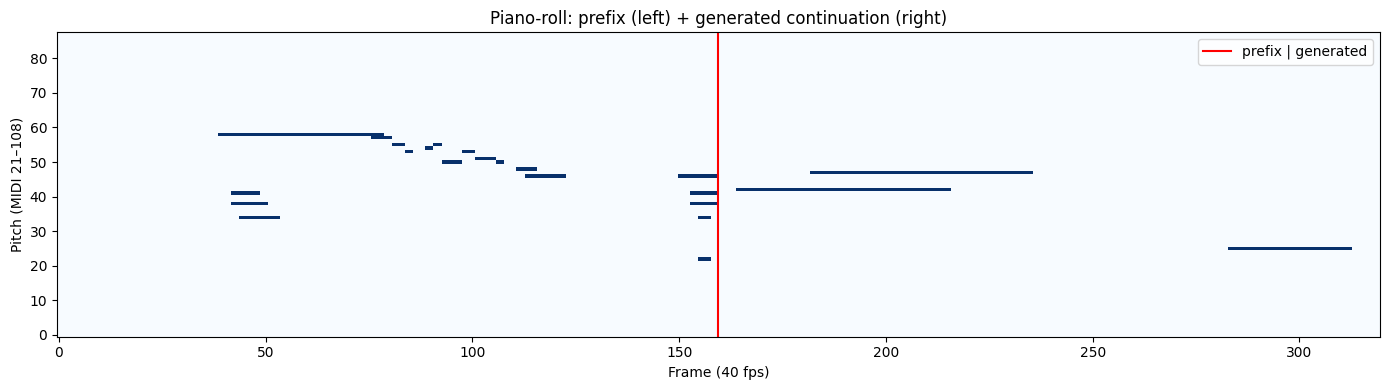

In [23]:
import matplotlib.pyplot as plt

prefix_roll = tokens_to_pianoroll(prefix_ids.tolist(), tokenizer,
                                  duration_seconds=OPTION2_PREFIX_SECONDS)
combined = np.concatenate([prefix_roll, model_roll], axis=0).T

split_frame = len(prefix_roll)
fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(combined, aspect='auto', origin='lower', cmap='Blues', interpolation='nearest')
ax.axvline(split_frame - 0.5, color='red', linewidth=1.5, label='prefix | generated')
ax.set_xlabel('Frame (40 fps)')
ax.set_ylabel('Pitch (MIDI 21–108)')
ax.set_title('Piano-roll: prefix (left) + generated continuation (right)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(OPTION2_OUTPUT_DIR / 'pianoroll_visualization.png', dpi=150)
plt.show()

## Done

| Output | Location |
|--------|----------|
| Generated MIDI | `outputs/option2/symbolic_conditioned.mid` |
| Best checkpoint | Google Drive `CSE253/option2_best.pt` (Colab) or `outputs/checkpoints/option2_best.pt` (local) |
| Loss curve | `outputs/option2/loss_curve.png` |
| Piano-roll plot | `outputs/option2/pianoroll_visualization.png` |